In [ ]:
import pyautogui
import pyperclip
import time
import pandas as pd
import os
import shutil
import glob
from datetime import datetime

pyautogui.FAILSAFE = False
pyautogui.PAUSE = 0.05

# ========== CALIBRATION ==========
SMILES_FIELD    = (201, 253)
SIMULATE_BTN    = (268, 692)
JCAMP_BTN       = (1205, 626)

FREQ_DROPDOWN   = (184, 766)
FREQ_60_MHz     = (155, 794)
FREQ_100_MHz    = (157, 814)
FREQ_500_MHz    = (155, 907)

NPOINTS_DROPDOWN = (182, 863)
NPOINTS_4K       = (158, 674)

SAVE_FOLDER      = r"C:\Users\pljh0187\Desktop\Senushi\JCAMP files"   # new folder
DOWNLOADS        = r"C:\Users\pljh0187\Downloads"
LOG_FILE         = os.path.join(r"C:\Users\pljh0187\Desktop\Senushi", "automation_log_book3.txt")

FREQ_OPTIONS = [
    (60,  FREQ_60_MHz),
    (100, FREQ_100_MHz),
    (500, FREQ_500_MHz),
]

# ========== READ Book3.csv (all compounds with ID) ==========
CSV_PATH = r"C:\Users\pljh0187\Desktop\Senushi\Book3.csv"
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

# Ensure required columns exist
if 'ID' not in df.columns:
    raise KeyError("Book3.csv must have an 'ID' column")
if 'Name' not in df.columns:
    raise KeyError("Book3.csv must have a 'Name' column")
if 'SMILES' not in df.columns:
    raise KeyError("Book3.csv must have a 'SMILES' column")

# Convert ID to zero-padded three-digit string (e.g., 1 -> "001")
df['ID'] = df['ID'].astype(str).str.zfill(3)

# Use all rows (all 502 compounds)
compounds = list(zip(df['ID'], df['Name'].str.strip(), df['SMILES'].str.strip()))
total = len(compounds)
print(f"Loaded {total} compounds from {CSV_PATH}")

# Create target folder if it doesn't exist
os.makedirs(SAVE_FOLDER, exist_ok=True)
# ===========================================================

def safe_filename(compound_id, freq):
    """New naming scheme: ID_freqMHz.jdx"""
    return f"{compound_id}_{freq}MHz.jdx"

def log(message):
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{ts}] {message}"
    print(line)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(line + "\n")

def wait_for_download(before_files, timeout=15):
    for _ in range(timeout * 2):
        time.sleep(0.5)
        current = set(glob.glob(os.path.join(DOWNLOADS, "*.jdx")) +
                      glob.glob(os.path.join(DOWNLOADS, "predictedSpectrum*")))
        new_files = current - before_files
        if new_files:
            return new_files.pop()
    return None

def rename_download(downloaded_path, compound_id, freq_mhz):
    """Move and rename to ID_freqMHz.jdx in SAVE_FOLDER"""
    filename = safe_filename(compound_id, freq_mhz)
    dest = os.path.join(SAVE_FOLDER, filename)
    shutil.move(downloaded_path, dest)
    return dest

def hover_and_paste(x, y, text, delay=0.8):
    pyperclip.copy(text)
    pyautogui.moveTo(x, y, duration=0.4)
    time.sleep(0.3)
    pyautogui.hotkey('ctrl', 'v')
    time.sleep(delay)

def hover_and_left_click_dropdown(x, y, delay=0.5):
    pyautogui.moveTo(x, y, duration=0.4)
    time.sleep(0.2)
    pyautogui.click()
    time.sleep(delay)

def hover_and_left_click(x, y, delay=0.5):
    pyautogui.moveTo(x, y, duration=0.4)
    time.sleep(0.2)
    pyautogui.click()
    time.sleep(delay)

def wait_and_click(x, y, delay=0.8):
    pyautogui.moveTo(x, y, duration=0.4)
    pyautogui.click()
    time.sleep(delay)

def clear_smiles_field():
    pyautogui.moveTo(*SMILES_FIELD, duration=0.4)
    time.sleep(0.2)
    pyautogui.hotkey('ctrl', 'a')
    time.sleep(0.1)
    pyautogui.press('delete')
    time.sleep(0.3)

def select_frequency(freq_mhz, freq_coord):
    hover_and_left_click_dropdown(*FREQ_DROPDOWN)
    hover_and_left_click(*freq_coord)

def select_4k_points():
    hover_and_left_click_dropdown(*NPOINTS_DROPDOWN)
    hover_and_left_click(*NPOINTS_4K)

def simulate_and_download(compound_id, name, freq_mhz, freq_coord):
    before = set(glob.glob(os.path.join(DOWNLOADS, "*.jdx")) +
                 glob.glob(os.path.join(DOWNLOADS, "predictedSpectrum*")))

    select_frequency(freq_mhz, freq_coord)
    time.sleep(0.3)
    select_4k_points()
    time.sleep(0.3)
    wait_and_click(*SIMULATE_BTN)
    time.sleep(3)
    wait_and_click(*JCAMP_BTN, delay=0)

    downloaded = wait_for_download(before, timeout=15)

    if downloaded:
        dest = rename_download(downloaded, compound_id, freq_mhz)
        log(f"SUCCESS | ID={compound_id} | {name} | {freq_mhz} MHz | saved as: {os.path.basename(dest)}")
    else:
        log(f"WARNING | ID={compound_id} | {name} | {freq_mhz} MHz | file not found in Downloads after 15s")

# ========== MAIN RUN ==========
log("=" * 60)
log(f"Starting NMR automation for Book3 — {total} compounds x 3 frequencies = {total*3} JCAMP files")
log(f"Save folder : {SAVE_FOLDER}")
log(f"CSV source  : {CSV_PATH}")
log("=" * 60)

print(f"Loaded {total} compounds. Files will be saved to: {SAVE_FOLDER}")
for i, (cid, name, smi) in enumerate(compounds, start=1):
    print(f"  [{i:03d}] ID={cid} : {name}")

print("Make sure the cheminfo.org page is open and visible.")
print("You have 5 seconds to click on the browser window...")
for i in range(5, 0, -1):
    print(f"  Starting in {i}...")
    time.sleep(1)
print("Starting now!")

start_time = time.time()
success_count = 0
warning_count = 0
error_count = 0

for idx, (cid, name, smiles) in enumerate(compounds, start=1):
    print(f"\n{'='*60}")
    log(f"Compound {idx}/{total} : ID={cid} | {name}")
    log(f"SMILES : {smiles}")

    if idx > 1:
        elapsed = time.time() - start_time
        avg_per = elapsed / (idx - 1)
        remaining = avg_per * (total - idx + 1) * 3 / 60
        log(f"Estimated time remaining: ~{remaining:.0f} minutes")

    try:
        clear_smiles_field()
        hover_and_paste(*SMILES_FIELD, smiles)
        time.sleep(0.5)

        for freq_mhz, freq_coord in FREQ_OPTIONS:
            log(f"Simulating at {freq_mhz} MHz ...")
            simulate_and_download(cid, name, freq_mhz, freq_coord)
            success_count += 1

        log(f"Finished: ID={cid} - {name}")

    except Exception as e:
        log(f"ERROR | ID={cid} | {name} | {e} — skipping to next compound")
        error_count += 1
        continue

elapsed_total = (time.time() - start_time) / 60
log("=" * 60)
log(f"All done!")
log(f"  Compounds processed : {total}")
log(f"  Total files         : {total*3}")
log(f"  Save location       : {SAVE_FOLDER}")
log(f"  Total time          : {elapsed_total:.1f} minutes")
log(f"  Log saved to        : {LOG_FILE}")
log("=" * 60)

Loaded 502 compounds from C:\Users\pljh0187\Desktop\Senushi\Book3.csv
[2026-06-01 16:17:54] ============================================================
[2026-06-01 16:17:54] Starting NMR automation for Book3 — 502 compounds x 3 frequencies = 1506 JCAMP files
[2026-06-01 16:17:54] Save folder : C:\Users\pljh0187\Desktop\Senushi\JCAMP files
[2026-06-01 16:17:54] CSV source  : C:\Users\pljh0187\Desktop\Senushi\Book3.csv
[2026-06-01 16:17:54] ============================================================
Loaded 502 compounds. Files will be saved to: C:\Users\pljh0187\Desktop\Senushi\JCAMP files
  [001] ID=001 : dimethyl fumarate
  [002] ID=002 : 3-nitro-1,2,4-triazol-5-one
  [003] ID=003 : nonanal
  [004] ID=004 : adenine
  [005] ID=005 : 4-aminobenzoic acid
  [006] ID=006 : 1,4-dichlorobenzene
  [007] ID=007 : adipic acid
  [008] ID=008 : naphthalene
  [009] ID=009 : diisopropylsulfide
  [010] ID=010 : 4-fluorobenzoic acid
  [011] ID=011 : cinnamic acid
  [012] ID=012 : 4-nitrotoluene
  [0

Convertion (JDX to CSV)

In [10]:
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

# ========== CONFIGURATION (MODIFIED) ==========
SOURCE_FOLDER = r"C:\Users\pljh0187\Desktop\test"
OUTPUT_FOLDER = r"C:\Users\pljh0187\Desktop\test"
LOG_FILE      = r"C:\Users\pljh0187\Desktop\Senushi\conversion_log_test.txt"
# ==============================================

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def log(message):
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{ts}] {message}"
    print(line)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(line + "\n")

# ---------------------------------------------------------------------------
# JCAMP-DX character encoding tables (JCAMP-DX 4.24 standard)
#   SQZ : encode absolute Y value   @ A-I a-i  →  0, +1..+9, -1..-9
#   DIF : encode difference from previous Y   % J-R j-r  →  0, +1..+9, -1..-9
#   DUP : repeat last value N times   S-Z s  →  1..9
# ---------------------------------------------------------------------------
SQZ = {
    '@': 0,
    'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5,
    'F': 6, 'G': 7, 'H': 8, 'I': 9,
    'a':-1, 'b':-2, 'c':-3, 'd':-4, 'e':-5,
    'f':-6, 'g':-7, 'h':-8, 'i':-9,
}
DIF = {
    '%': 0,
    'J': 1, 'K': 2, 'L': 3, 'M': 4, 'N': 5,
    'O': 6, 'P': 7, 'Q': 8, 'R': 9,
    'j':-1, 'k':-2, 'l':-3, 'm':-4, 'n':-5,
    'o':-6, 'p':-7, 'q':-8, 'r':-9,
}
DUP = {'S':1,'T':2,'U':3,'V':4,'W':5,'X':6,'Y':7,'Z':8,'s':9}


def tokenize(line):
    """
    Tokenize one JCAMP data line into (type, value) pairs.
    Types: 'X' (first token = X position), 'SQZ' (absolute Y),
           'DIF' (Y difference), 'DUP' (repeat count).
    """
    tokens = []
    i = 0
    first_token = True

    while i < len(line):
        c = line[i]

        if c in (' ', '\t', ','):
            i += 1
            continue

        if c in SQZ:
            sign   = -1 if (c.islower() and c != '@') else 1
            digits = str(abs(SQZ[c]))
            i += 1
            while i < len(line) and (line[i].isdigit() or line[i] == '.'):
                digits += line[i]; i += 1
            val = sign * float(digits)
            tokens.append(('X' if first_token else 'SQZ', val))
            first_token = False

        elif c in DIF:
            sign   = -1 if c.islower() else 1
            digits = str(abs(DIF[c]))
            i += 1
            while i < len(line) and (line[i].isdigit() or line[i] == '.'):
                digits += line[i]; i += 1
            val = sign * float(digits)
            tokens.append(('DIF', val))
            first_token = False

        elif c in DUP:
            digits = str(DUP[c])
            i += 1
            while i < len(line) and line[i].isdigit():
                digits += line[i]; i += 1
            tokens.append(('DUP', int(digits)))

        elif c.isdigit() or c in ('+', '-'):
            digits = c; i += 1
            while i < len(line) and (line[i].isdigit() or line[i] == '.'):
                digits += line[i]; i += 1
            val = float(digits)
            tokens.append(('X' if first_token else 'SQZ', val))
            first_token = False

        else:
            i += 1  # skip unknown characters

    return tokens


def parse_jcamp(filepath):
    """
    Parse a JCAMP-DX NMR file.
    Returns a DataFrame with columns: chemical_shift_ppm, intensity
    Handles:
      - XYDATA=(X++(Y..Y))  with SQZ / DIF / DUP compression  ← cheminfo.org format
      - XYPOINTS=(XY..XY)   simple X,Y pairs
    The X values in the data block are raw integer indices; the real ppm value
    is  index × deltax  (deltax is already in ppm units in these files).
    """
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        raw_lines = f.readlines()

    # --- parse header ---
    xfactor  = 1.0
    yfactor  = 1.0
    npoints  = None
    deltax   = None
    firstx   = None
    lastx    = None
    data_fmt = None
    data_lines   = []
    xypts_lines  = []
    in_xydata    = False
    in_xypoints  = False

    for line in raw_lines:
        s = line.rstrip("\n").strip()
        u = s.upper()

        if   u.startswith("##XFACTOR="):  xfactor = float(s.split("=",1)[1])
        elif u.startswith("##YFACTOR="):  yfactor = float(s.split("=",1)[1])
        elif u.startswith("##NPOINTS="):  npoints = int(s.split("=",1)[1])
        elif u.startswith("##DELTAX="):   deltax  = float(s.split("=",1)[1])
        elif u.startswith("##FIRSTX="):   firstx  = float(s.split("=",1)[1])
        elif u.startswith("##LASTX="):    lastx   = float(s.split("=",1)[1])
        elif u.startswith("##XYDATA="):
            data_fmt    = s.split("=",1)[1].strip()
            in_xydata   = True
            in_xypoints = False
        elif u.startswith("##XYPOINTS="):
            in_xypoints = True
            in_xydata   = False
        elif u.startswith("##END"):
            in_xydata = in_xypoints = False
        elif in_xydata:
            data_lines.append(s)
        elif in_xypoints:
            xypts_lines.append(s)

    # ----------------------------------------------------------------
    # Format A: XYPOINTS — simple pairs (rare for simulated NMR)
    # ----------------------------------------------------------------
    if xypts_lines:
        xs, ys = [], []
        for line in xypts_lines:
            parts = line.replace(",", " ").split()
            if len(parts) >= 2:
                try:
                    xs.append(float(parts[0]) * xfactor)
                    ys.append(float(parts[1]) * yfactor)
                except ValueError:
                    pass
        return pd.DataFrame({"chemical_shift_ppm": xs, "intensity": ys})

    # ----------------------------------------------------------------
    # Format B: XYDATA=(X++(Y..Y))  — compressed (cheminfo.org default)
    # X on each data line is a RAW INTEGER INDEX into the spectrum array.
    # Gaps between segments are zero (sparse storage of NMR peaks).
    # ----------------------------------------------------------------
    if npoints is None or npoints < 1:
        raise ValueError("NPOINTS not found or invalid")
    if deltax is None:
        if firstx is not None and lastx is not None and npoints > 1:
            deltax = (lastx - firstx) / (npoints - 1)
        else:
            raise ValueError("Cannot determine deltax")

    y_array = np.zeros(npoints, dtype=np.float64)

    for line in data_lines:
        if not line:
            continue
        tokens = tokenize(line)
        if not tokens:
            continue

        # First token = raw X index
        x_idx = int(round(tokens[0][1]))
        if x_idx >= npoints:
            continue  # trailing checksum line (e.g. "40950@")

        pos        = x_idx
        last_y     = 0.0
        last_dif   = 0.0
        in_dif_mode = False

        for t_type, t_val in tokens[1:]:

            if t_type == 'SQZ':
                y = t_val * yfactor
                if pos < npoints:
                    y_array[pos] = y
                pos += 1
                last_y = y
                in_dif_mode = False

            elif t_type == 'DIF':
                diff = t_val * yfactor
                y    = last_y + diff
                if pos < npoints:
                    y_array[pos] = y
                pos += 1
                last_y     = y
                last_dif   = diff
                in_dif_mode = True

            elif t_type == 'DUP':
                count = int(t_val) - 1  # first copy already stored
                if in_dif_mode:
                    for _ in range(count):
                        y = last_y + last_dif
                        if pos < npoints:
                            y_array[pos] = y
                        pos += 1
                        last_y = y
                else:
                    for _ in range(count):
                        if pos < npoints:
                            y_array[pos] = last_y
                        pos += 1

    x_array = np.array([i * deltax for i in range(npoints)], dtype=np.float64)

    return pd.DataFrame({"chemical_shift_ppm": x_array, "intensity": y_array})


def convert_jcamp_to_csv(jdx_path, output_folder):
    stem     = Path(jdx_path).stem
    out_path = os.path.join(output_folder, stem + ".csv")
    df       = parse_jcamp(jdx_path)
    if df.empty or len(df) == 0:
        return False, "No data parsed"
    df.to_csv(out_path, index=False)
    return True, out_path


# ========== MAIN ==========
jdx_files = sorted(glob.glob(os.path.join(SOURCE_FOLDER, "*.jdx")))
total     = len(jdx_files)

log("=" * 60)
log(f"JCAMP-DX → CSV Conversion")
log(f"Found {total} .jdx files in: {SOURCE_FOLDER}")
log(f"Output folder            : {OUTPUT_FOLDER}")
log("=" * 60)

success_count = 0
fail_count    = 0

for i, jdx_path in enumerate(jdx_files, start=1):
    fname = os.path.basename(jdx_path)
    try:
        ok, result = convert_jcamp_to_csv(jdx_path, OUTPUT_FOLDER)
        if ok:
            log(f"[{i:04d}/{total}] OK   | {fname}")
            success_count += 1
        else:
            log(f"[{i:04d}/{total}] FAIL | {fname} — {result}")
            fail_count += 1
    except Exception as e:
        log(f"[{i:04d}/{total}] ERR  | {fname} — {e}")
        fail_count += 1

log("=" * 60)
log(f"Done!  {success_count} converted,  {fail_count} failed.")
log(f"CSVs saved to: {OUTPUT_FOLDER}")
log("=" * 60)

[2026-06-24 16:45:33] ============================================================
[2026-06-24 16:45:33] JCAMP-DX → CSV Conversion
[2026-06-24 16:45:33] Found 1 .jdx files in: C:\Users\pljh0187\Desktop\test
[2026-06-24 16:45:33] Output folder            : C:\Users\pljh0187\Desktop\test
[2026-06-24 16:45:33] ============================================================
[2026-06-24 16:45:33] [0001/1] OK   | predictedSpectrum - 2026-06-24T164125.851.jdx
[2026-06-24 16:45:33] ============================================================
[2026-06-24 16:45:33] Done!  1 converted,  0 failed.
[2026-06-24 16:45:33] CSVs saved to: C:\Users\pljh0187\Desktop\test
[2026-06-24 16:45:33] ============================================================


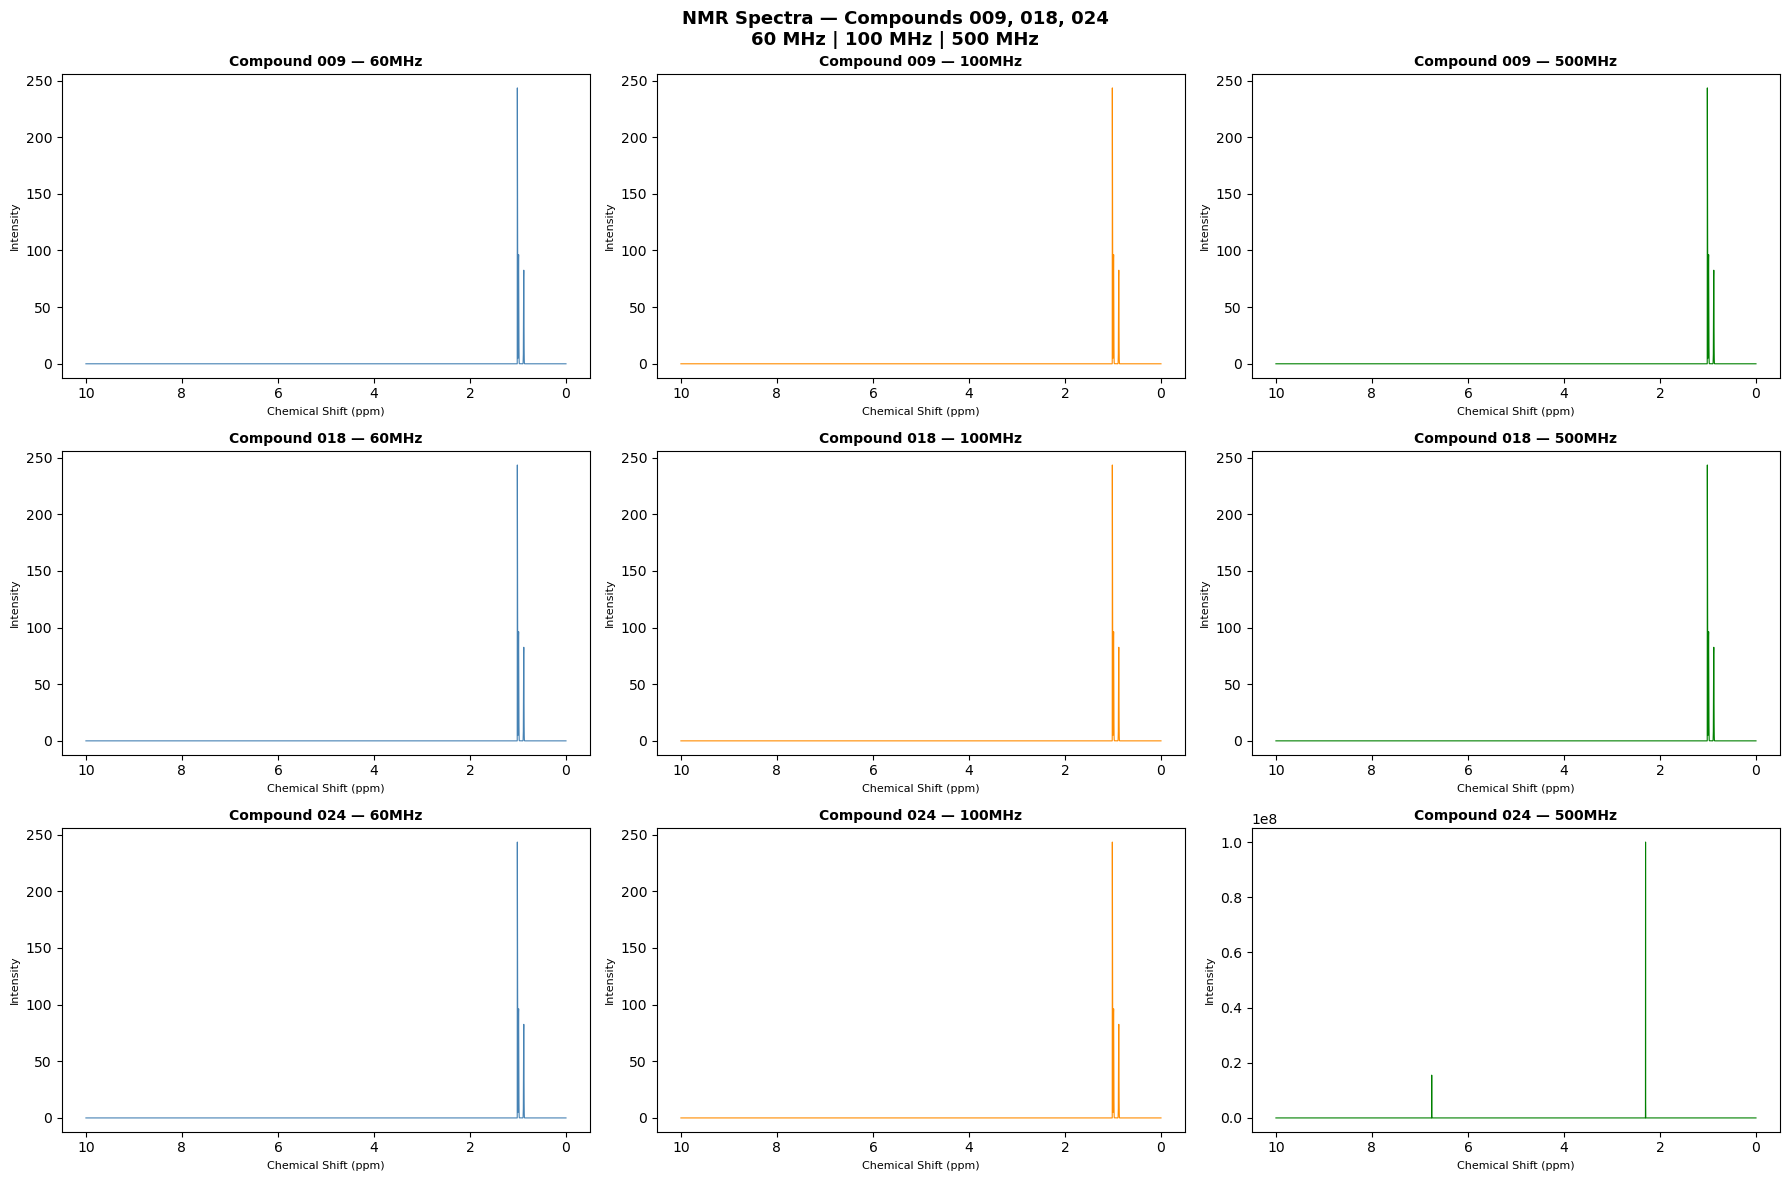

Plot saved to: C:\Users\pljh0187\Desktop\Senushi\nmr_spectra_009_018_024.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ─────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────

base_path   = r"C:\Users\pljh0187\Desktop\Senushi\CSV files"
output_path = r"C:\Users\pljh0187\Desktop\Senushi"

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

compounds   = ['009', '018', '024']
frequencies = ['60MHz', '100MHz', '500MHz']

colors = {
    '60MHz':  'steelblue',
    '100MHz': 'darkorange',
    '500MHz': 'green'
}

# ─────────────────────────────────────────────
# PLOT — One row per compound, one column per frequency
# ─────────────────────────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row, compound in enumerate(compounds):
    for col, freq in enumerate(frequencies):

        ax       = axes[row, col]
        filename = f"{compound}_{freq}.csv"
        filepath = os.path.join(base_path, filename)

        if not os.path.exists(filepath):
            ax.set_title(f'Compound {compound} — {freq}\nFILE NOT FOUND', fontsize=9)
            ax.text(0.5, 0.5, 'File not found',
                    ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='red')
            continue

        df = pd.read_csv(filepath)

        # Auto-detect columns
        cols      = {c.lower(): c for c in df.columns}
        shift_col = cols.get('chemical shift') or cols.get('shift') or df.columns[0]
        inten_col = cols.get('intensity') or df.columns[1]

        ax.plot(df[shift_col], df[inten_col],
                color=colors[freq], linewidth=0.8)

        ax.set_title(f'Compound {compound} — {freq}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Chemical Shift (ppm)', fontsize=8)
        ax.set_ylabel('Intensity', fontsize=8)
        ax.invert_xaxis()   # NMR convention: high ppm on left
        ax.grid(False)

plt.suptitle('NMR Spectra — Compounds 009, 018, 024\n'
             '60 MHz | 100 MHz | 500 MHz',
             fontsize=13, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(output_path, "nmr_spectra_009_018_024.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {save_path}")

JDX to CSV fpr compound 18 (60MHz, 100MHz and 500 MHz)

In [2]:
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

# ========== CONFIGURATION (UPDATED FOR YOUR FILES) ==========
SOURCE_FOLDER = r"C:\Users\pljh0187\Documents\jdx"
OUTPUT_FOLDER = r"C:\Users\pljh0187\Documents\jdx\CSV_output"  # saves CSVs in a subfolder
LOG_FILE      = r"C:\Users\pljh0187\Documents\jdx\conversion_log.txt"
# ============================================================

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def log(message):
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{ts}] {message}"
    print(line)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(line + "\n")

# ---------------------------------------------------------------------------
# JCAMP-DX character encoding tables (SQZ, DIF, DUP)
# ---------------------------------------------------------------------------
SQZ = {
    '@': 0,
    'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5,
    'F': 6, 'G': 7, 'H': 8, 'I': 9,
    'a':-1, 'b':-2, 'c':-3, 'd':-4, 'e':-5,
    'f':-6, 'g':-7, 'h':-8, 'i':-9,
}
DIF = {
    '%': 0,
    'J': 1, 'K': 2, 'L': 3, 'M': 4, 'N': 5,
    'O': 6, 'P': 7, 'Q': 8, 'R': 9,
    'j':-1, 'k':-2, 'l':-3, 'm':-4, 'n':-5,
    'o':-6, 'p':-7, 'q':-8, 'r':-9,
}
DUP = {'S':1,'T':2,'U':3,'V':4,'W':5,'X':6,'Y':7,'Z':8,'s':9}


def tokenize(line):
    """Tokenize one JCAMP data line into (type, value) pairs."""
    tokens = []
    i = 0
    first_token = True

    while i < len(line):
        c = line[i]

        if c in (' ', '\t', ','):
            i += 1
            continue

        if c in SQZ:
            sign   = -1 if (c.islower() and c != '@') else 1
            digits = str(abs(SQZ[c]))
            i += 1
            while i < len(line) and (line[i].isdigit() or line[i] == '.'):
                digits += line[i]; i += 1
            val = sign * float(digits)
            tokens.append(('X' if first_token else 'SQZ', val))
            first_token = False

        elif c in DIF:
            sign   = -1 if c.islower() else 1
            digits = str(abs(DIF[c]))
            i += 1
            while i < len(line) and (line[i].isdigit() or line[i] == '.'):
                digits += line[i]; i += 1
            val = sign * float(digits)
            tokens.append(('DIF', val))
            first_token = False

        elif c in DUP:
            digits = str(DUP[c])
            i += 1
            while i < len(line) and line[i].isdigit():
                digits += line[i]; i += 1
            tokens.append(('DUP', int(digits)))

        elif c.isdigit() or c in ('+', '-'):
            digits = c; i += 1
            while i < len(line) and (line[i].isdigit() or line[i] == '.'):
                digits += line[i]; i += 1
            val = float(digits)
            tokens.append(('X' if first_token else 'SQZ', val))
            first_token = False

        else:
            i += 1

    return tokens


def parse_jcamp(filepath):
    """Parse a JCAMP-DX NMR file and return DataFrame."""
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        raw_lines = f.readlines()

    # --- parse header ---
    xfactor  = 1.0
    yfactor  = 1.0
    npoints  = None
    deltax   = None
    firstx   = None
    lastx    = None
    data_fmt = None
    data_lines   = []
    xypts_lines  = []
    in_xydata    = False
    in_xypoints  = False

    for line in raw_lines:
        s = line.rstrip("\n").strip()
        u = s.upper()

        if   u.startswith("##XFACTOR="):  xfactor = float(s.split("=",1)[1])
        elif u.startswith("##YFACTOR="):  yfactor = float(s.split("=",1)[1])
        elif u.startswith("##NPOINTS="):  npoints = int(s.split("=",1)[1])
        elif u.startswith("##DELTAX="):   deltax  = float(s.split("=",1)[1])
        elif u.startswith("##FIRSTX="):   firstx  = float(s.split("=",1)[1])
        elif u.startswith("##LASTX="):    lastx   = float(s.split("=",1)[1])
        elif u.startswith("##XYDATA="):
            data_fmt    = s.split("=",1)[1].strip()
            in_xydata   = True
            in_xypoints = False
        elif u.startswith("##XYPOINTS="):
            in_xypoints = True
            in_xydata   = False
        elif u.startswith("##END"):
            in_xydata = in_xypoints = False
        elif in_xydata:
            data_lines.append(s)
        elif in_xypoints:
            xypts_lines.append(s)

    # ------------------------------------------------
    # Format A: XYPOINTS — simple X,Y pairs
    # ------------------------------------------------
    if xypts_lines:
        xs, ys = [], []
        for line in xypts_lines:
            parts = line.replace(",", " ").split()
            if len(parts) >= 2:
                try:
                    xs.append(float(parts[0]) * xfactor)
                    ys.append(float(parts[1]) * yfactor)
                except ValueError:
                    pass
        return pd.DataFrame({"chemical_shift_ppm": xs, "intensity": ys})

    # ------------------------------------------------
    # Format B: XYDATA=(X++(Y..Y)) — compressed
    # ------------------------------------------------
    if npoints is None or npoints < 1:
        raise ValueError("NPOINTS not found or invalid")
    if deltax is None:
        if firstx is not None and lastx is not None and npoints > 1:
            deltax = (lastx - firstx) / (npoints - 1)
        else:
            raise ValueError("Cannot determine deltax")

    y_array = np.zeros(npoints, dtype=np.float64)

    for line in data_lines:
        if not line:
            continue
        tokens = tokenize(line)
        if not tokens:
            continue

        x_idx = int(round(tokens[0][1]))
        if x_idx >= npoints:
            continue

        pos        = x_idx
        last_y     = 0.0
        last_dif   = 0.0
        in_dif_mode = False

        for t_type, t_val in tokens[1:]:

            if t_type == 'SQZ':
                y = t_val * yfactor
                if pos < npoints:
                    y_array[pos] = y
                pos += 1
                last_y = y
                in_dif_mode = False

            elif t_type == 'DIF':
                diff = t_val * yfactor
                y    = last_y + diff
                if pos < npoints:
                    y_array[pos] = y
                pos += 1
                last_y     = y
                last_dif   = diff
                in_dif_mode = True

            elif t_type == 'DUP':
                count = int(t_val) - 1
                if in_dif_mode:
                    for _ in range(count):
                        y = last_y + last_dif
                        if pos < npoints:
                            y_array[pos] = y
                        pos += 1
                        last_y = y
                else:
                    for _ in range(count):
                        if pos < npoints:
                            y_array[pos] = last_y
                        pos += 1

    x_array = np.array([i * deltax for i in range(npoints)], dtype=np.float64)

    return pd.DataFrame({"chemical_shift_ppm": x_array, "intensity": y_array})


def convert_jcamp_to_csv(jdx_path, output_folder):
    stem     = Path(jdx_path).stem
    out_path = os.path.join(output_folder, stem + ".csv")
    df       = parse_jcamp(jdx_path)
    if df.empty or len(df) == 0:
        return False, "No data parsed"
    df.to_csv(out_path, index=False)
    return True, out_path


# ========== MAIN ==========
# Find all .jdx files – this will pick up your three files
jdx_files = sorted(glob.glob(os.path.join(SOURCE_FOLDER, "*.jdx")))
total     = len(jdx_files)

log("=" * 60)
log(f"JCAMP-DX → CSV Conversion")
log(f"Found {total} .jdx files in: {SOURCE_FOLDER}")
log(f"Output folder            : {OUTPUT_FOLDER}")
log("=" * 60)

success_count = 0
fail_count    = 0

for i, jdx_path in enumerate(jdx_files, start=1):
    fname = os.path.basename(jdx_path)
    try:
        ok, result = convert_jcamp_to_csv(jdx_path, OUTPUT_FOLDER)
        if ok:
            log(f"[{i:04d}/{total}] OK   | {fname}")
            success_count += 1
        else:
            log(f"[{i:04d}/{total}] FAIL | {fname} — {result}")
            fail_count += 1
    except Exception as e:
        log(f"[{i:04d}/{total}] ERR  | {fname} — {e}")
        fail_count += 1

log("=" * 60)
log(f"Done!  {success_count} converted,  {fail_count} failed.")
log(f"CSVs saved to: {OUTPUT_FOLDER}")
log("=" * 60)

[2026-06-24 16:24:47] ============================================================
[2026-06-24 16:24:47] JCAMP-DX → CSV Conversion
[2026-06-24 16:24:47] Found 3 .jdx files in: C:\Users\pljh0187\Documents\jdx
[2026-06-24 16:24:47] Output folder            : C:\Users\pljh0187\Documents\jdx\CSV_output
[2026-06-24 16:24:47] ============================================================
[2026-06-24 16:24:47] [0001/3] OK   | 18(100MHz).jdx
[2026-06-24 16:24:47] [0002/3] OK   | 18(500MHz).jdx
[2026-06-24 16:24:47] [0003/3] OK   | 18(60MHz).jdx
[2026-06-24 16:24:47] ============================================================
[2026-06-24 16:24:47] Done!  3 converted,  0 failed.
[2026-06-24 16:24:47] CSVs saved to: C:\Users\pljh0187\Documents\jdx\CSV_output
[2026-06-24 16:24:47] ============================================================


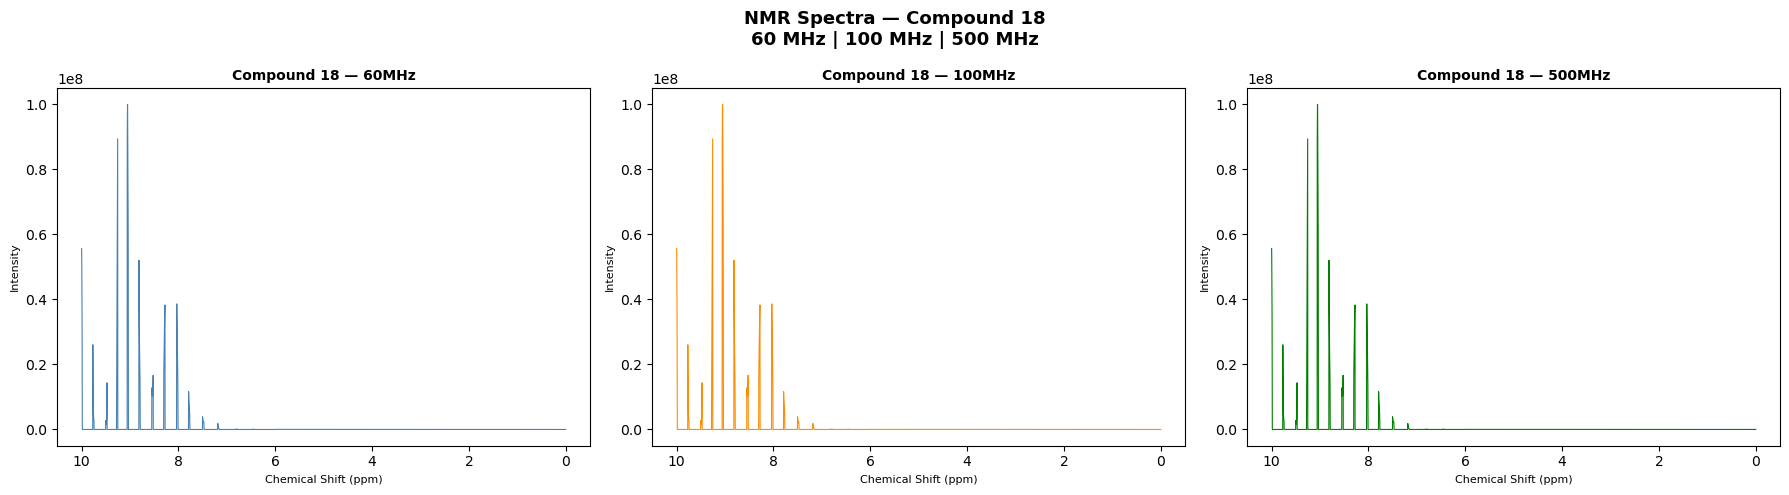

Plot saved to: C:\Users\pljh0187\Desktop\test\nmr_spectra_compound_18.png


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ─────────────────────────────────────────────
# PATHS (update if your CSVs are elsewhere)
# ─────────────────────────────────────────────

base_path   = r"C:\Users\pljh0187\Desktop\test"
output_path = r"C:\Users\pljh0187\Desktop\test"

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

compound    = '18'
frequencies = ['60MHz', '100MHz', '500MHz']

colors = {
    '60MHz':  'steelblue',
    '100MHz': 'darkorange',
    '500MHz': 'green'
}

# ─────────────────────────────────────────────
# PLOT — 1 row, 3 columns
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, freq in enumerate(frequencies):

    ax       = axes[col]
    filename = f"test.csv"      # e.g. "18(60MHz).csv"
    filepath = os.path.join(base_path, filename)

    if not os.path.exists(filepath):
        ax.set_title(f'Compound {compound} — {freq}\nFILE NOT FOUND', fontsize=9)
        ax.text(0.5, 0.5, 'File not found',
                ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='red')
        continue

    df = pd.read_csv(filepath)

    # Direct column names (as confirmed)
    shift_col = 'chemical_shift_ppm'
    inten_col = 'intensity'

    ax.plot(df[shift_col], df[inten_col],
            color=colors[freq], linewidth=0.8)

    ax.set_title(f'Compound {compound} — {freq}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Chemical Shift (ppm)', fontsize=8)
    ax.set_ylabel('Intensity', fontsize=8)
    ax.invert_xaxis()
    ax.grid(False)

plt.suptitle(f'NMR Spectra — Compound {compound}\n'
             '60 MHz | 100 MHz | 500 MHz',
             fontsize=13, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(output_path, "nmr_spectra_compound_18.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {save_path}")